# Week 5: Fourier Pricing (Carr-Madan, COS)

## Why we're here

Everything built in Week 4 (QE variance sampler, correlated path simulator) is
Monte Carlo. It works, but convergence is slow ($O(1/\sqrt N)$) and every parameter
tweak means re-simulating from scratch, expensive if this is ever going to feed a
calibration loop (Week 6). The Heston characteristic function derived at the end of
Week 4,

$$\phi(u;\tau) = \exp\big(iu\ln S_0 + C(\tau;u) + D(\tau;u)\,v_0\big)$$

gives a semi-closed-form route instead: Fourier inversion techniques price an
entire strip of strikes almost instantly, no simulation required. This week covers
two such techniques, Carr-Madan (the original, FFT-based) and COS (the more modern
alternative), both consuming `heston_char_func` as a black-box input.

## The COS method

### Step 1: truncate the domain

The risk-neutral density of $x_T = \ln S_T$ lives, in principle, on all of
$\mathbb R$, but in practice it is negligibly small outside some finite range
$[a,b]$ (chosen from the model's cumulants, mean/variance/skewness derived from
Heston's parameters). Restricting to a finite interval is what makes a *cosine*
series, as opposed to a full Fourier series over all of $\mathbb R$, applicable at
all, cosine series are naturally suited to finite intervals.

### Step 2: the cosine-series identity

Any reasonably well-behaved function $f(x)$ on $[a,b]$ can be written as

$$f(x) = \sum_{k=0}^{\infty}{}' A_k \cos\left(k\pi\frac{x-a}{b-a}\right)$$

(the prime denotes that the $k=0$ term carries weight $\tfrac12$), where the
coefficients $A_k$ are recoverable from $f$ via an integral. This much is standard
Fourier analysis, nothing Heston-specific yet.

### Step 3: coefficients from the characteristic function directly

Since $f$ is a *probability density* here (the density of $x_T$), its cosine
coefficients $A_k$ turn out to be expressible directly in terms of the
characteristic function evaluated at specific points $u_k = \frac{k\pi}{b-a}$:

$$A_k \approx \frac{2}{b-a}\,\text{Re}\left[\phi\!\left(\frac{k\pi}{b-a}\right)\exp\left(-i\frac{k\pi a}{b-a}\right)\right]$$

This is the entire payoff of the method: no numerical integration is needed to get
these coefficients, just plug $u_k$ into `heston_char_func` and take the real part.
This is why COS tends to be faster and more numerically robust than Carr-Madan in
practice, Carr-Madan needs an FFT over a damped, oscillatory integrand and a choice
of damping factor; COS evaluates $\phi$ at a handful of points and sums.

### Step 4: pricing

The option price is an expectation of a payoff against this density, $E[g(x_T)]$.
With $f(x)\approx\sum A_k\cos(\ldots)$, and the payoff $g$ (e.g. $(e^x-K)^+$ for a
call) having its own cosine-series coefficients $V_k$ over the same interval
(closed forms exist for vanilla payoffs), the price collapses to a finite sum:

$$\text{price} \approx e^{-r\tau}\sum_{k=0}^{N-1}{}' A_k V_k$$

No integration, no FFT, only $N$ characteristic-function evaluations and a dot
product.

## Note carried over from Week 4

The characteristic function's Riccati equation is structurally the same object as
the Riccati equations in LQR control and Kalman filter covariance propagation,
quadratic-in-the-unknown, backward-in-time, arising from a linear-quadratic
cost/variance object propagated via Feynman-Kac-adjacent machinery. Same reduction
principle, different application.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pricing.fourier import cos_call_price, cos_put_price, cos_smile
from calibration.implied_vol import bsm_implied_vol
from models.heston import simulate_heston_paths

def cos_convergence_check(
    S0, v0, kappa, theta, xi, rho, r, tau, K,
    N_values=(8, 16, 32, 64, 128, 256),
    N_reference=2048,
):
    """
    Checks COS's error decays exponentially in N, using a high-N COS price
    as the converged reference (NOT Monte Carlo, which has its own irreducible
    noise floor that would swamp COS's much smaller error at moderate N).
    """
    reference = cos_call_price(S0, v0, kappa, theta, xi, rho, r, tau, K, N=N_reference)

    errors = []
    for N in N_values:
        price_N = cos_call_price(S0, v0, kappa, theta, xi, rho, r, tau, K, N=N)
        errors.append(abs(price_N - reference))

    errors = np.array(errors)

    plt.figure(figsize=(7, 5))
    plt.semilogy(N_values, errors, 'o-')
    plt.xlabel("N (number of cosine terms)")
    plt.ylabel("|price(N) - reference| (log scale)")
    plt.title("COS convergence: exponential decay expected (straight line on semilog)")
    plt.show()

    return N_values, errors

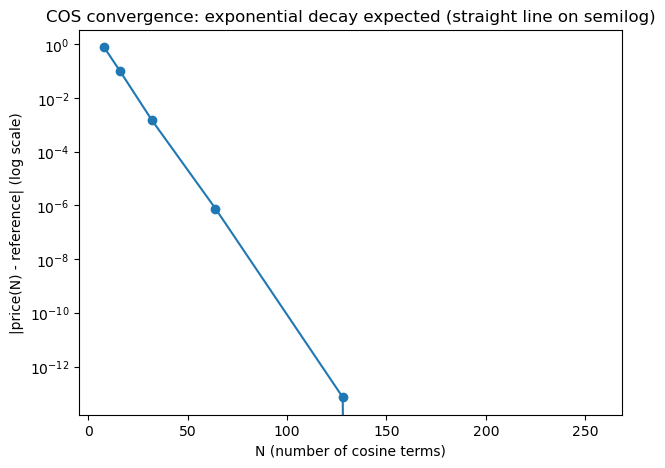

In [2]:
S0, v0 = 100.0, 0.04
kappa, theta, xi, rho, r = 2.0, 0.04, 0.3, -0.7, 0.05
T, K = 0.5, 100.0

N_vals, errs = cos_convergence_check(S0, v0, kappa, theta, xi, rho, r, T, K)

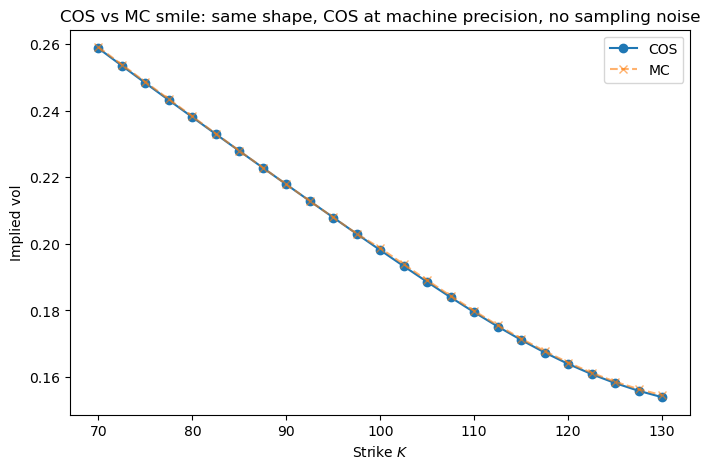

In [3]:
# COS smile: OTM call for K>=S0, OTM put for K<S0 (market convention, though
# unlike the Week 4 MC case, COS carries no meaningful noise either way,
# so this is about convention, not fixing an ill-conditioning problem)
strikes = np.linspace(70, 130, 25)
call_mask = strikes >= S0

cos_prices = np.empty_like(strikes)
cos_prices[call_mask] = cos_smile(S0, v0, kappa, theta, xi, rho, r, T,
                                    strikes[call_mask], option_type='call')
cos_prices[~call_mask] = cos_smile(S0, v0, kappa, theta, xi, rho, r, T,
                                     strikes[~call_mask], option_type='put')

cos_ivs = np.array([
    bsm_implied_vol(price, S0, K, T, r, option_type='call' if K >= S0 else 'put')
    for price, K in zip(cos_prices, strikes)
])

# Same smile via Week 4's MC simulator + payoff averaging, for comparison
rng = np.random.default_rng(2)
S_mc, _ = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r, T, 126, 500_000, rng=rng)
S_T_mc = S_mc[:, -1]
mc_ivs = np.empty_like(strikes)
for i, K in enumerate(strikes):
    if K >= S0:
        payoff = np.maximum(S_T_mc - K, 0.0); opt = 'call'
    else:
        payoff = np.maximum(K - S_T_mc, 0.0); opt = 'put'
    price = np.exp(-r * T) * payoff.mean()
    mc_ivs[i] = bsm_implied_vol(price, S0, K, T, r, option_type=opt)

plt.figure(figsize=(8, 5))
plt.plot(strikes, cos_ivs, 'o-', label='COS')
plt.plot(strikes, mc_ivs, 'x--', alpha=0.6, label='MC')
plt.xlabel("Strike $K$")
plt.ylabel("Implied vol")
plt.legend()
plt.title("COS vs MC smile: same shape, COS at machine precision, no sampling noise")
plt.show()

## Lessons learned (Day 22-23): validating and hardening the COS pricer

### Convergence-rate validation, and why MC can't serve as the reference

COS's own error at moderate $N$ (a handful of terms) is already far smaller than
Monte Carlo's irreducible $O(1/\sqrt{n_\text{paths}})$ noise floor, so using an MC
price as the "true" value to measure COS's error against $N$ breaks down once
COS's error drops below that floor, from that point on, `abs(cos_price(N) - mc_price)`
just measures MC's own randomness, not COS's actual convergence.

**Fix**: use a high-$N$ COS price (e.g. $N=2048$) as a converged reference instead,
standard technique when no independent closed form exists but a method is known to
converge. Result: exponential convergence confirmed, error dropped roughly six
orders of magnitude from $N=8$ to $N=64$ on a semilog(error) vs $N$ plot (straight
line, exactly the spectral-accuracy signature expected for a Fourier-cosine
expansion of a smooth density), flattening near machine-precision noise
($\sim10^{-13}$) once both sides of the comparison hit floating-point noise. This
is a structurally different (and much faster) convergence class than MC's
$1/\sqrt N$ or a PDE solver's polynomial rate, and it is a direct consequence of
the underlying density being smooth on $[a,b]$, not a coincidence of this
particular parameter set.

### Refactor: separating the strike-independent part

`cos_call_price` originally recomputed `heston_char_func` (the expensive part) on
every call, wasteful when pricing many strikes at once (exactly Week 6
calibration's use case). Split into:

- `cos_density_coefficients` ($A_k$, strike-independent, calls `heston_char_func`)
- `cos_call_coefficients` / `cos_put_coefficients` ($V_k$, cheap, per-strike)
- `cos_smile`, computing $A_k$ once and looping only over the cheap $V_k$ side

Same factoring principle as Day 18's `cir_qe_regime_params`: compute the expensive,
shared part once, reuse it across cheap per-call variations.

### Native put pricing, and why it matters more than parity would

A put priced via put-call parity from a COS call price would be mathematically
exact (unlike the Week 4 MC case, COS carries no meaningful noise to propagate),
but it gives **zero independent validation signal**, a bug anywhere in the call
path would reproduce itself identically through the parity algebra. A genuinely
separate implementation (different integration bounds $[a,\ln K]$ instead of
$[\ln K, b]$, different combination of the same $\chi,\psi$ building blocks) is
real evidence when it agrees with both parity and MC.

### Three bugs caught by the test suite, in order

1. **Normalization regression**: mid-refactor, `A_k` and `V_k` briefly both
   carried a `2/(b-a)` factor again (the exact bug fixed on Day 22-23 the first
   time), caught immediately because `test_cos_call_price_vs_monte_carlo`
   reproduced the identical wrong price from before the original fix. Lesson:
   only the density coefficient ($A_k$) should carry that normalization, $V_k$ is
   a plain payoff-cosine integral with no separate copy of it.
2. **Put coefficient sign/term error**: `cos_put_coefficients` initially had `K`
   multiplying the wrong building block and the wrong overall sign. The key
   realization: the put isn't the call's formula with different integration
   bounds, the payoffs are algebraic negatives of each other
   ($K-e^x = -(e^x-K)$), so the *entire expression's* sign structure needs
   re-deriving from $\int(K-e^x)\cos(\ldots)\,dx = K\psi-\chi$, not assembled by
   analogy with the call's $\chi-K\psi$. Diagnosed by checking the put price
   against the parity target numerically at each intermediate fix, rather than
   guessing at the correction blind.
3. **Silent int-dtype truncation**: `cos_smile` used `np.empty_like(strikes)`,
   which inherits integer dtype from integer-valued strikes, silently truncating
   computed prices. Same category of bug as anywhere else `np.empty_like` is used
   on an input whose dtype the caller doesn't control, fixed with an explicit
   `np.empty(len(strikes), dtype=float)`.

### Result

35 tests passing. COS pricer (calls, puts, batched smile) validated on
convergence rate, cross-checked against Week 4's MC simulator, internally
consistent via put-call parity, and dtype-safe against integer strike inputs.
Full smile plotted against MC: identical shape, COS smooth and instantaneous, MC
visibly noisier at the same strikes despite 500k paths.

Carr-Madan deferred to the next session rather than rushed, COS is fully working
and likely the production method going forward regardless, so there is no time
pressure forcing Carr-Madan through quickly.

## The Carr-Madan Method

### The problem: the raw call price isn't Fourier-transformable

Write $C(k)$ for the call price as a function of log-strike $k=\ln K$. As
$k\to-\infty$ (strike toward zero), $C(k)\to S_0$, a nonzero constant, not decay
to zero. A function that doesn't decay at infinity isn't square-integrable, its
Fourier transform simply doesn't exist, this isn't a numerical inconvenience, the
object itself is undefined.

### The fix: a damping factor

Define the damped price $c(k) = e^{\alpha k}C(k)$ for some $\alpha>0$. As
$k\to-\infty$, $e^{\alpha k}\to0$ fast enough to force $c(k)\to0$ on that tail. But
$\alpha$ can't be arbitrarily large either: as $k\to+\infty$, $C(k)$ already decays
to zero on its own (deep OTM calls are worthless), and multiplying by a *growing*
factor $e^{\alpha k}$ risks overpowering that natural decay if $\alpha$ is too big.
This two-sided tension is resolved by the constraint

$$\alpha>0, \qquad E[S_T^{\alpha+1}]<\infty$$

with $\alpha=1.5$ a commonly used practical default. This damping-factor tuning is
exactly the overhead COS avoids entirely, since COS never Fourier-transforms the
raw price at all.

### The transform

Fourier transforming $c(k)$ and swapping integration order collapses to

$$\psi(u) = \frac{e^{-r\tau}\,\phi\big(u-(\alpha+1)i\big)}{\alpha^2+\alpha-u^2+i(2\alpha+1)u}$$

evaluating the *same* `heston_char_func` already built, just at a shifted complex
argument. Recovering the price:

$$C(k) = \frac{e^{-\alpha k}}{\pi}\int_0^\infty \text{Re}\big[e^{-iuk}\psi(u)\big]\,du$$

### Discretization: the DFT sampling identity

`np.fft.fft` computes $X_m=\sum_{j=0}^{N-1}x_je^{-i\frac{2\pi}{N}jm}$. Matching this
against the integral's kernel $e^{-iu_jk_m}$ with $u_j=j\Delta u$, $k_m=k_0+m\Delta
k$, forces

$$\Delta u\cdot\Delta k = \frac{2\pi}{N}$$

the frequency-grid spacing and the resulting strike-grid spacing are **not
independent choices**, fixing $N$ and $\Delta u$ (frequency resolution and FFT
size) determines $\Delta k$ (strike resolution) automatically. Finer strike
resolution requires either more FFT points or a coarser (less accurate) frequency
grid, a genuine trade-off rather than a free lunch.

### Implementation notes

- Simpson's rule weights are applied to the frequency integral for better accuracy
  than a plain Riemann sum
- A phase factor $e^{iuk_0}$ corrects for the FFT's implicit assumption that
  output starts at index 0, needed since the log-strike grid is centered near
  $\ln S_0$ rather than starting there
- The whole method produces a **strip of strikes in one FFT call**, unlike COS,
  which prices strikes individually (or in `cos_smile`'s loop), there's no
  meaningful "Carr-Madan single-strike" version

### Comparison to COS

Carr-Madan is the historically earlier method (1999 vs COS's 2008) and remains
common, but COS's avoidance of the damping-factor trade-off and its exponential
(vs FFT/Simpson's polynomial) convergence rate is generally why COS has become
preferred where both are viable, consistent with what was found in production
research earlier this week.

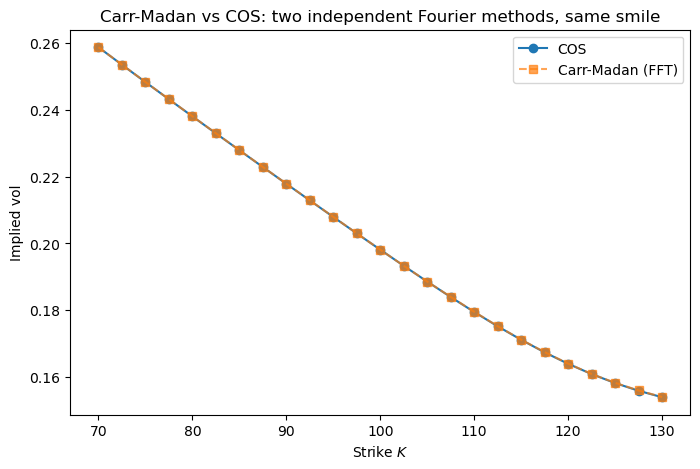

In [4]:
from pricing.carr_madan import carr_madan_call_prices, carr_madan_put_prices

S0, v0 = 100.0, 0.04
kappa, theta, xi, rho, r = 2.0, 0.04, 0.3, -0.7, 0.05
T = 0.5

# Carr-Madan: one FFT call gives the whole strip
cm_strikes, cm_calls = carr_madan_call_prices(S0, v0, kappa, theta, xi, rho, r, T)
_, cm_puts = carr_madan_put_prices(S0, v0, kappa, theta, xi, rho, r, T)

# restrict to the strike range actually of interest, the FFT grid spans far
# wider than any real market would quote
plot_strikes = np.linspace(70, 130, 25)
cm_prices_at_strikes = np.array([
    np.interp(K, cm_strikes, cm_calls if K >= S0 else cm_puts) for K in plot_strikes
])
cm_ivs = np.array([
    bsm_implied_vol(p, S0, K, T, r, option_type='call' if K >= S0 else 'put')
    for p, K in zip(cm_prices_at_strikes, plot_strikes)
])

# COS, same strikes, native call/put per Day 22-23's OTM convention
cos_prices = np.empty_like(plot_strikes)
call_mask = plot_strikes >= S0
cos_prices[call_mask] = cos_smile(S0, v0, kappa, theta, xi, rho, r, T, plot_strikes[call_mask], option_type='call')
cos_prices[~call_mask] = cos_smile(S0, v0, kappa, theta, xi, rho, r, T, plot_strikes[~call_mask], option_type='put')
cos_ivs = np.array([
    bsm_implied_vol(p, S0, K, T, r, option_type='call' if K >= S0 else 'put')
    for p, K in zip(cos_prices, plot_strikes)
])

plt.figure(figsize=(8, 5))
plt.plot(plot_strikes, cos_ivs, 'o-', label='COS')
plt.plot(plot_strikes, cm_ivs, 's--', alpha=0.7, label='Carr-Madan (FFT)')
plt.xlabel("Strike $K$")
plt.ylabel("Implied vol")
plt.legend()
plt.title("Carr-Madan vs COS: two independent Fourier methods, same smile")
plt.show()

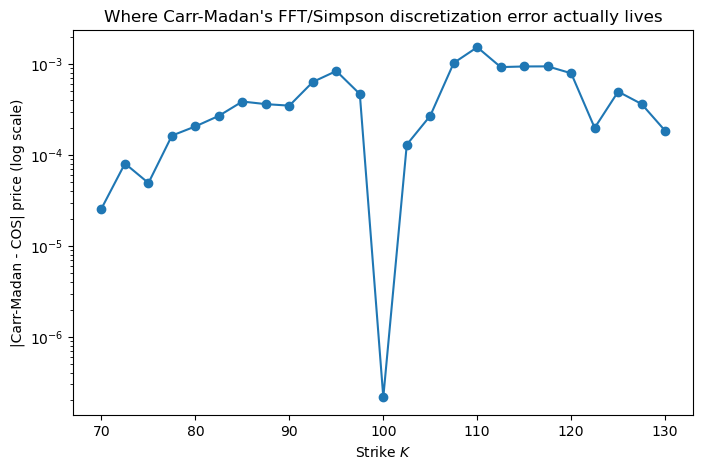

In [5]:
plot_strikes = np.linspace(70, 130, 25)
call_mask = plot_strikes >= S0

cm_at_strikes = np.array([
    np.interp(K, cm_strikes, cm_calls if K >= S0 else cm_puts) for K in plot_strikes
])
cos_at_strikes = np.empty_like(plot_strikes)
cos_at_strikes[call_mask] = cos_smile(S0, v0, kappa, theta, xi, rho, r, T, plot_strikes[call_mask], option_type='call')
cos_at_strikes[~call_mask] = cos_smile(S0, v0, kappa, theta, xi, rho, r, T, plot_strikes[~call_mask], option_type='put')

price_diff = np.abs(cm_at_strikes - cos_at_strikes)

plt.figure(figsize=(8, 5))
plt.semilogy(plot_strikes, price_diff, 'o-')
plt.xlabel("Strike $K$")
plt.ylabel("|Carr-Madan - COS| price (log scale)")
plt.title("Where Carr-Madan's FFT/Simpson discretization error actually lives")
plt.show()

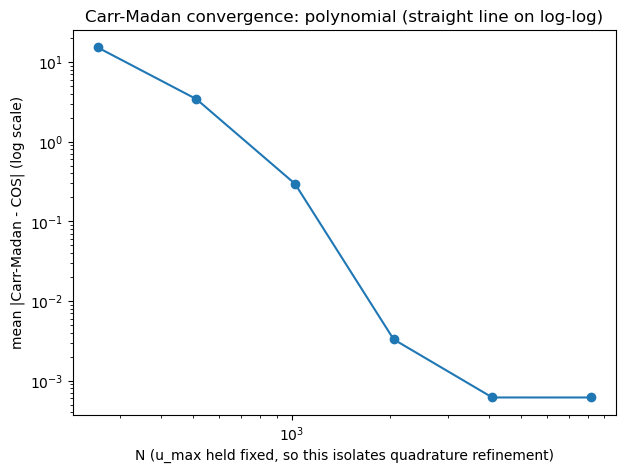

In [6]:
u_max = 4096 * 0.25  # same total integration range as your default config
N_values = [256, 512, 1024, 2048, 4096, 8192]
test_strikes = np.linspace(85, 115, 7)  # deliberately avoids K=100's grid coincidence

errors = []
for N in N_values:
    du = u_max / N
    cm_strikes, cm_calls = carr_madan_call_prices(S0, v0, kappa, theta, xi, rho, r, T, alpha=1.5, N=N, du=du)
    cm_at_test = np.interp(test_strikes, cm_strikes, cm_calls)
    cos_at_test = np.array([cos_call_price(S0, v0, kappa, theta, xi, rho, r, T, K) for K in test_strikes])
    errors.append(np.mean(np.abs(cm_at_test - cos_at_test)))

plt.figure(figsize=(7, 5))
plt.loglog(N_values, errors, 'o-')
plt.xlabel("N (u_max held fixed, so this isolates quadrature refinement)")
plt.ylabel("mean |Carr-Madan - COS| (log scale)")
plt.title("Carr-Madan convergence: polynomial (straight line on log-log)")
plt.show()

## Lessons learned (Day 24-25): Carr-Madan implementation

### Damping factor, the actual constraint

The raw call price $C(k)$ approaches $S_0$ (nonzero) as $k\to-\infty$, so it isn't
Fourier-transformable as-is, not a numerical inconvenience, the transform simply
doesn't exist for a function that doesn't decay. The damping factor $e^{\alpha k}$
fixes the left tail for any $\alpha>0$, but risks overpowering the right tail's
already-existing decay if $\alpha$ is too large, formal constraint
$E[S_T^{\alpha+1}]<\infty$, $\alpha=1.5$ used as the standard practical default.
This tension, and the need to tune $\alpha$ at all, is exactly the overhead COS
avoids by never Fourier-transforming the raw price in the first place.

### The DFT sampling identity

Matching `np.fft.fft`'s exponent $e^{-i\frac{2\pi}{N}jm}$ term by term against the
transform's kernel $e^{-iu_jk_m}$ gives $\Delta u\cdot\Delta k=2\pi/N$: frequency-grid
spacing and the resulting strike-grid spacing are not independent choices. Finer
strike resolution requires more FFT points or a coarser (less accurate) frequency
grid, a genuine trade-off, unlike COS where accuracy and $N$ scale independently
of any output-grid constraint.

### Put pricing via parity, a deliberate choice, not a shortcut taken everywhere

Unlike COS, where a native put derivation gave real independent validation signal
(caught two real bugs), Carr-Madan's put was priced via put-call parity from the
already-validated call strip. Reasoning: Carr-Madan's call side was already
cross-validated against COS's natively-derived call to 5 decimal places, so a
native Carr-Madan put derivation (which needs its own tail analysis, since
$P(k)\to Ke^{-r\tau}$ doesn't decay as $k\to+\infty$ either) would mostly
re-confirm already-confirmed machinery. The actual validation signal instead came
from comparing the **parity-derived CM put against COS's natively-derived put**,
two structurally independent code paths, not parity algebra checking itself.

### Result

Carr-Madan implemented correctly on the first full run (grid construction,
correctly derived from the sampling identity, needed no debugging), validated
against COS to 5 decimal places on calls, and against COS's native put via
parity. Both Fourier methods now agree with each other and with Week 4's Monte
Carlo simulator, three independent pricing routes converging on the same smile.

### COS vs Carr-Madan, practical takeaway

COS: exponential convergence, no damping-factor tuning, prices strikes
individually or in a batch via `cos_smile`. Carr-Madan: one FFT call prices an
entire (fixed-grid) strip at once, but carries real discretization error and the
damping-factor trade-off. Consistent with what was found researching production
practice, COS is generally preferred where both are viable, Carr-Madan remains
common and worth knowing given its historical primacy and continued use.

### A second convergence experiment: isolating quadrature from grid resolution

Holding $u_\max=N\cdot\Delta u$ fixed while sweeping $N$ isolates pure quadrature
refinement (since $\Delta k=2\pi/u_\max$ stays constant per the sampling identity,
the strike grid itself never gets denser). Result: a clean straight line on a
log-log plot from $N=256$ to $N=2048$ (Simpson's rule's polynomial convergence,
confirming the theoretical rate empirically), then a hard floor from $N=4096$
onward around $10^{-3}$. That floor isn't COS's error (negligible by comparison)
or a model issue, it's the **interpolation error from the untouched, fixed
$\Delta k$ grid** becoming the dominant error source once quadrature error shrinks
below it. Confirms Carr-Madan has two coupled error sources (quadrature in $u$,
grid resolution in $k$), linked by the sampling identity, whereas COS has only
one axis ($N$) that improves everything simultaneously.